### Imports

In [1]:
import json
from datetime import datetime
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from c50py import C5Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from itertools import product
from sklearn.metrics import f1_score

### Dataset

In [2]:
dataset = pd.read_csv(
    "../dataset/datasets/full_v5.csv"
)

### Prepare predictors, target, and subject groups


In [3]:
split = dataset["split"].astype("string").str.lower()
expected_splits = {"train", "test"}
unknown_splits = set(split.dropna().unique()) - expected_splits
if unknown_splits:
    raise ValueError(f"Unexpected values in 'split': {sorted(unknown_splits)}")

# The split column controls the partition and must not be used as a feature.
X = dataset.drop(columns=["Activity", "subject", "split"])
y_text = dataset["Activity"]
groups = dataset["subject"]

### Encode target labels

In [4]:
le = LabelEncoder()
y = pd.Series(
    le.fit_transform(y_text),
    index=y_text.index,
    name="Activity",
)

### Dataset-defined train/test split 

In [5]:
train_mask = split.eq("train")
test_mask = split.eq("test")

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]
groups_train = groups.loc[train_mask]
groups_test = groups.loc[test_mask]

print("Training subjects:", sorted(groups_train.unique()))
print("Test subjects:", sorted(groups_test.unique()))
print("Subject overlap:", set(groups_train.unique()) & set(groups_test.unique()))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

# Five-fold group-aware cross-validation for hyperparameter tuning
cv = GroupKFold(n_splits=5)

Training subjects: [np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(23), np.int64(24), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Test subjects: [np.int64(3), np.int64(9), np.int64(14), np.int64(15), np.int64(16), np.int64(20), np.int64(22), np.int64(25), np.int64(26)]
Subject overlap: set()
Training rows: 7177
Test rows: 3122


### Train C5.0

#### Define hyperparameter grid 

In [6]:
from sklearn.feature_selection import mutual_info_classif


def winnow_features(X_fit, y_fit):
    """Screen weak numeric predictors using only fold training data."""
    numeric_columns = X_fit.select_dtypes(include="number").columns
    if len(numeric_columns) == 0:
        return list(X_fit.columns)

    scores = mutual_info_classif(
        X_fit[numeric_columns],
        y_fit,
        random_state=69,
        discrete_features="auto",
    )
    score_series = pd.Series(scores, index=numeric_columns)
    threshold = score_series.max() * 0.10
    selected_numeric = score_series[score_series >= threshold].index.tolist()
    if not selected_numeric:
        selected_numeric = [score_series.idxmax()]

    non_numeric_columns = [
        column for column in X_fit.columns if column not in numeric_columns
    ]
    return selected_numeric + non_numeric_columns


param_grid = {
    "winnow": [True, False],
    "global_pruning": [True, False],
    "min_samples_leaf": [2, 5, 10],
}

# Generate all parameter combinations
param_keys = list(param_grid.keys())
param_combinations = [
    dict(zip(param_keys, values))
    for values in product(*param_grid.values())
]

best_score = -1.0
best_params = None
best_features = None

print(f"Testing {len(param_combinations)} hyperparameter combinations...")

Testing 12 hyperparameter combinations...


#### Grid search

In [7]:
for params in param_combinations:
    fold_scores = []

    for fold, (train_idx, validation_idx) in enumerate(
        cv.split(X_train, y_train, groups=groups_train),
        start=1,
    ):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_validation = X_train.iloc[validation_idx]
        y_fold_train = y_train.iloc[train_idx]

        if params["winnow"]:
            selected_features = winnow_features(X_fold_train, y_fold_train)
        else:
            selected_features = list(X_fold_train.columns)

        model_params = {
            key: value for key, value in params.items() if key != "winnow"
        }
        candidate_model = C5Classifier(**model_params)
        candidate_model.fit(X_fold_train[selected_features], y_fold_train)

        validation_pred = candidate_model.predict(
            X_fold_validation[selected_features]
        )
        fold_f1 = f1_score(
            y_train.iloc[validation_idx],
            validation_pred,
            average="macro",
            zero_division=0,
        )
        fold_scores.append(fold_f1)
        print(
            f"  Fold {fold}: {fold_f1:.4f} "
            f"({len(selected_features)}/{X_fold_train.shape[1]} features)"
        )

    mean_validation_f1 = sum(fold_scores) / len(fold_scores)
    print(
        f"{params} -> 5-fold validation macro F1: "
        f"{mean_validation_f1:.4f} "
        f"(folds: {[round(score, 4) for score in fold_scores]})"
    )

    if mean_validation_f1 > best_score:
        best_score = mean_validation_f1
        best_params = params.copy()

print("\n--- Tuning Complete ---")
print(f"Best 5-fold Validation Macro F1: {best_score:.4f}")
print("Best Hyperparameters:", best_params)


  Fold 1: 0.8180 (179/217 features)
  Fold 2: 0.8125 (176/217 features)
  Fold 3: 0.8557 (177/217 features)
  Fold 4: 0.8883 (176/217 features)
  Fold 5: 0.9007 (183/217 features)
{'winnow': True, 'global_pruning': True, 'min_samples_leaf': 2} -> 5-fold validation macro F1: 0.8550 (folds: [0.818, 0.8125, 0.8557, 0.8883, 0.9007])
  Fold 1: 0.8486 (179/217 features)
  Fold 2: 0.8255 (176/217 features)
  Fold 3: 0.8477 (177/217 features)
  Fold 4: 0.8876 (176/217 features)
  Fold 5: 0.8864 (183/217 features)
{'winnow': True, 'global_pruning': True, 'min_samples_leaf': 5} -> 5-fold validation macro F1: 0.8591 (folds: [0.8486, 0.8255, 0.8477, 0.8876, 0.8864])
  Fold 1: 0.8696 (179/217 features)
  Fold 2: 0.8103 (176/217 features)
  Fold 3: 0.8617 (177/217 features)
  Fold 4: 0.8371 (176/217 features)
  Fold 5: 0.9094 (183/217 features)
{'winnow': True, 'global_pruning': True, 'min_samples_leaf': 10} -> 5-fold validation macro F1: 0.8576 (folds: [0.8696, 0.8103, 0.8617, 0.8371, 0.9094])
  Fo

#### Refit the selected configuration using all training subjects


In [8]:
if best_params["winnow"]:
    final_features = winnow_features(X_train, y_train)
else:
    final_features = list(X_train.columns)

model_params = {
    key: value for key, value in best_params.items() if key != "winnow"
}
best_model = C5Classifier(**model_params)
best_model.fit(X_train[final_features], y_train)
print(f"Final model features: {len(final_features)}/{X_train.shape[1]}")
c5_model = best_model

Final model features: 217/217


### Predict

In [9]:
y_pred = c5_model.predict(X_test[final_features])
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Macro F1: {test_f1:.4f}")


Final Test Accuracy: 0.8434
Final Test Macro F1: 0.8406


### Evaluate using the original activity names

In [10]:
labels = list(range(len(le.classes_)))
class_names = le.classes_.tolist()

report = classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true",
).round(4).tolist()

### Logging

In [11]:
model_name = "c5.0_v4 Decision Tree"
dataset_name = "full_v5"
note = "N/A"

report = classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true",
).round(4).tolist()

# Capture constructor parameters without relying on c50py's broken get_params().
c5_parameter_names = [
    "trials",
    "min_samples_split",
    "min_samples_leaf",
    "pruning",
    "cf",
    "global_pruning",
    "random_state",
    "feature_names",
    "categorical_features",
    "infer_categorical",
    "int_as_categorical",
    "max_categories_exhaustive",
    "numeric_threshold_strategy",
    "max_numeric_thresholds",
    "max_depth",
    "mdl_penalty",
    "gain_ratio_avg_gain",
    "verbose",
]
c5_params = {
    name: (
        getattr(c5_model, "feature_names_", None)
        if name == "feature_names"
        else getattr(c5_model, name, None)
    )
    for name in c5_parameter_names
}

record = {
    "timestamp": datetime.now().isoformat(),
    "dataset": dataset_name,
    "model": model_name,
    "note": note or "N/A",
    "overall_accuracy": float(accuracy_score(y_test, y_pred)),
    "macro_f1": float(report["macro avg"]["f1-score"]),
    "classes": class_names,
    "confusion_matrix_percent": cm_normalized,
    "classification_report": report,
    "params": {
        "learning_rate": None,
        "max_depth": c5_params.get("max_depth"),
        "n_estimators": None,
        "num_round": None,
        "subsample": None,
        "colsample_bytree": None,
        "min_child_weight": None,
        "c5_specific": c5_params,
    },
}

with open("results.jsonl", "a", encoding="utf-8") as f:
    f.write(json.dumps(record) + "\n")

print(
    f"Logged {record['model']} on dataset "
    f"'{record['dataset']}' to results.jsonl"
)


Logged c5.0_v4 Decision Tree on dataset 'full_v5' to results.jsonl


Confusion Matrix:
                            Predicted: LAYING  Predicted: SITTING  \
Actual: LAYING                            592                   0   
Actual: SITTING                             0                 439   
Actual: STANDING                            0                 123   
Actual: WALKING                             0                   0   
Actual: WALKING_DOWNSTAIRS                  0                   0   
Actual: WALKING_UPSTAIRS                    0                   0   

                            Predicted: STANDING  Predicted: WALKING  \
Actual: LAYING                                0                   1   
Actual: SITTING                             116                   0   
Actual: STANDING                            454                   0   
Actual: WALKING                               0                 390   
Actual: WALKING_DOWNSTAIRS                    0                   8   
Actual: WALKING_UPSTAIRS                      2                  21   



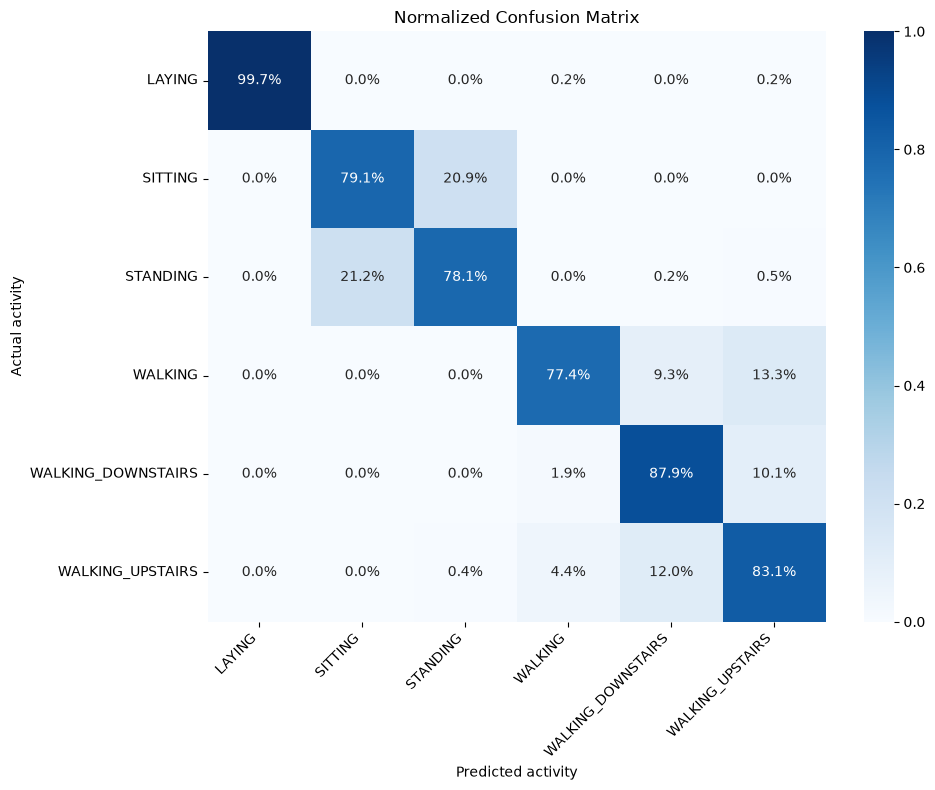

In [12]:
# Raw confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion Matrix:")
print(
    pd.DataFrame(
        cm,
        index=[f"Actual: {name}" for name in class_names],
        columns=[f"Predicted: {name}" for name in class_names],
    )
)

# Normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted activity")
plt.ylabel("Actual activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()